In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv('Laptop_price.csv')

In [4]:
df

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718
...,...,...,...,...,...,...,...
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459


In [5]:
df.shape

(1000, 7)

In [6]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [7]:
df.sample(10)

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
688,Dell,2.311465,32,512,15.562546,3.940512,18116.165591
147,Lenovo,3.574355,32,512,14.076358,4.416578,18492.162113
117,Lenovo,2.523529,16,256,12.044490,2.004039,9415.942553
179,Dell,2.155660,8,1000,16.925958,4.708117,31442.695182
807,Lenovo,2.387491,16,1000,11.822537,3.195927,31720.062940
980,Lenovo,3.220337,4,1000,14.392520,3.292575,31665.884014
873,Asus,3.543624,32,1000,14.458835,3.233612,32948.390259
762,Acer,3.599653,16,512,16.950176,3.129245,17606.220338
974,Asus,2.648617,8,1000,16.322716,3.872722,31374.559669
970,Asus,3.343393,4,256,13.585903,2.261328,9106.686029


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [9]:
df.isnull().sum()

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [10]:
for i in df.columns:
  print(i, ':', df[i].unique())
  print('*'*50)

Brand : ['Asus' 'Acer' 'Lenovo' 'HP' 'Dell']
**************************************************
Processor_Speed : [3.83029571 2.91283296 3.24162706 3.80624845 3.26809659 1.88134761
 2.9407209  3.01678762 2.56032668 3.34111059 3.83591754 3.81392128
 2.62709843 1.78309511 3.962103   3.59724522 1.8116567  3.80210471
 3.67474091 2.79709514 2.97818859 2.49750676 1.6369041  2.3379931
 3.50713362 1.51158006 2.33374793 2.49542173 2.84348901 3.79963904
 2.36586499 2.367383   3.34375312 2.63054485 2.06151206 2.63109879
 1.85214255 1.94096747 2.74591943 2.54731362 3.78711475 2.40598475
 2.95147088 3.08066072 1.53273614 3.15884343 1.94508992 3.90267579
 1.87165682 2.53656031 1.71337417 3.99218563 2.75548753 2.98846254
 1.66769119 3.37490118 2.02476398 3.74513572 2.0128491  1.9767193
 1.59137417 2.68016736 2.91210283 1.6642716  3.43881904 2.63322209
 2.81097567 2.60190687 2.50190765 2.89910083 1.88810061 1.95482033
 3.65446405 3.86528866 2.43327329 2.17686168 3.10999886 2.52183543
 1.56346589 1.890

In [11]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


Brand
Dell      210
Asus      206
Acer      204
Lenovo    190
HP        190
Name: count, dtype: int64

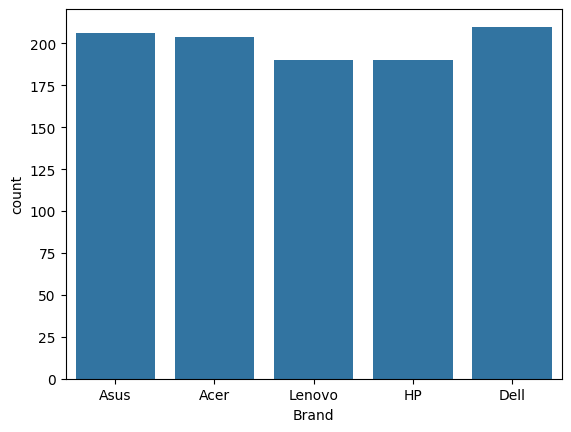

In [12]:
sns.countplot(x='Brand',data=df)
df['Brand'].value_counts()

<Axes: ylabel='count'>

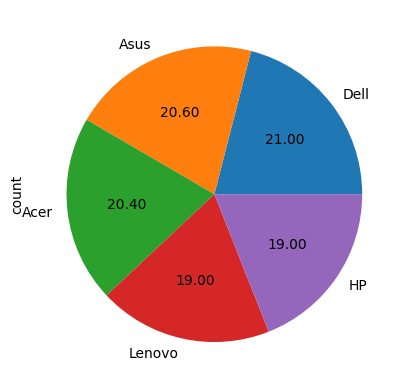

In [13]:
df['Brand'].value_counts().plot(kind='pie', autopct='%.2f')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
col = ['Processor_Speed', 'Screen_Size', 'Weight']

In [16]:
df['Processor_Speed'] = round(df['Processor_Speed'], 2)

In [17]:
df['Screen_Size'] = round(df['Screen_Size'], 2)

In [18]:
df['Weight'] = round(df['Weight'], 2)

In [19]:
df

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.83,16,512,11.19,2.64,17395.093065
1,Acer,2.91,4,1000,11.31,3.26,31607.605919
2,Lenovo,3.24,4,256,11.85,2.03,9291.023542
3,Acer,3.81,16,512,12.28,4.57,17436.728334
4,Acer,3.27,32,1000,14.99,4.19,32917.990718
...,...,...,...,...,...,...,...
995,HP,3.34,4,1000,12.59,3.16,31593.668017
996,Dell,2.78,8,256,12.68,3.75,9149.521832
997,Dell,3.20,4,512,12.67,3.39,16552.404779
998,Asus,1.60,8,256,11.22,3.86,9407.473459


In [20]:
df['Price'] = round(df['Price'], 2)

In [21]:
df

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.83,16,512,11.19,2.64,17395.09
1,Acer,2.91,4,1000,11.31,3.26,31607.61
2,Lenovo,3.24,4,256,11.85,2.03,9291.02
3,Acer,3.81,16,512,12.28,4.57,17436.73
4,Acer,3.27,32,1000,14.99,4.19,32917.99
...,...,...,...,...,...,...,...
995,HP,3.34,4,1000,12.59,3.16,31593.67
996,Dell,2.78,8,256,12.68,3.75,9149.52
997,Dell,3.20,4,512,12.67,3.39,16552.40
998,Asus,1.60,8,256,11.22,3.86,9407.47


In [22]:
X = df.drop('Price', axis=1)
y = df['Price']

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
X_train = pd.get_dummies(X_train, columns=['Brand'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Brand'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [26]:
X_train.head()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
29,3.80,8,1000,12.85,2.15,True,False,False,False
535,3.30,16,512,15.14,2.59,False,False,False,False
695,2.43,4,512,15.05,2.26,False,False,True,False
557,3.31,32,512,12.84,2.38,False,False,False,False
836,3.16,16,512,14.70,2.94,False,False,True,False


In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [29]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9996440003071116
MAE: 146.27236740829386
RMSE: 179.7874992483771


In [30]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [31]:
y_pred_rf = rf.predict(X_test)

In [32]:
print('R2:', r2_score(y_test, y_pred_rf))

R2: 0.9995370815267407


In [33]:
df.corr(numeric_only=True)

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
Processor_Speed,1.000000,0.021208,-0.067429,-0.013305,-0.054842,-0.050600
RAM_Size,0.021208,1.000000,0.002111,-0.036062,-0.025530,0.061237
Storage_Capacity,-0.067429,0.002111,1.000000,-0.027537,0.041372,0.997908
Screen_Size,-0.013305,-0.036062,-0.027537,1.000000,0.022169,-0.026718
Weight,-0.054842,-0.025530,0.041372,0.022169,1.000000,0.038449
Price,-0.050600,0.061237,0.997908,-0.026718,0.038449,1.000000


In [34]:
print(X_train.columns)

Index(['Processor_Speed', 'RAM_Size', 'Storage_Capacity', 'Screen_Size',
       'Weight', 'Brand_Asus', 'Brand_Dell', 'Brand_HP', 'Brand_Lenovo'],
      dtype='object')


In [35]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price               1.000000
Storage_Capacity    0.997908
RAM_Size            0.061237
Weight              0.038449
Screen_Size        -0.026718
Processor_Speed    -0.050600
Name: Price, dtype: float64

In [36]:
df.sample(1)

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
227,HP,3.93,16,1000,12.53,4.22,31901.47


In [37]:
new_data = pd.DataFrame({
    'Processor_Speed': [2.31],
    'RAM_Size': [8],
    'Storage_Capacity': [256],
    'Screen_Size': [15.09],
    'Weight': [2.22],
    'Brand_Asus': [0],
    'Brand_Dell': [0],
    'Brand_HP': [1],
    'Brand_Lenovo': [0]
})

In [38]:
predicted_price = model.predict(new_data)
print("Predicted Price:", predicted_price[0])

Predicted Price: 9318.318670932958


In [39]:
predicted_price = model.predict(new_data)
print("Predicted Price:", predicted_price[0])

Predicted Price: 9318.318670932958


In [40]:
predicted_price = rf.predict(new_data)
print("Predicted Price:", predicted_price[0])

Predicted Price: 9235.243999999997


In [41]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [42]:
pip install streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.1 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.1 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.1 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.1 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.1 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 1.8/9.1 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.4/9.1 MB 1.3 MB/s eta 0:00:06
   ----------- ---------------------------- 2.6/9.1 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.1 MB 1.4 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.1 MB 1.4 MB/s eta 0:00:05
   ----------------- -----

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
